In [ ]:
Name: Nikhil Sanjay Patil

Roll no 06

PRN:12311506

Class: CSAI-B Batch 1


Problem Statement:Assignment No. 5 :Learn Decision trees for regression and classification problem

a. Split the data set into training and test sets.

b. Build the decision tree

c. Check model performances on training and test data sets.

d. Apply cost complexity pruning to overcome overfitting problem

e. Apply Random Forest algorithm to overcome overfitting problem.

f. Apply Ada-boost ensemble method on Decision stumps.

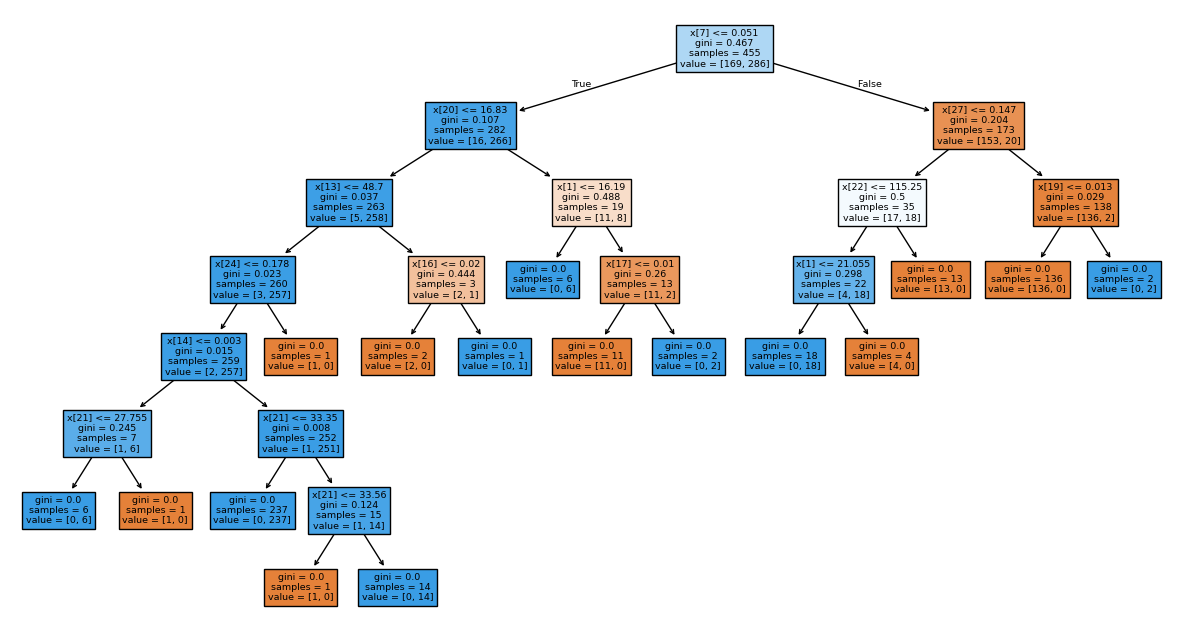

Training Accuracy: 1.0
Testing Accuracy: 0.9473684210526315
Accuracy after pruning: 0.9473684210526315
Random Forest Accuracy: 0.9649122807017544
AdaBoost Accuracy: 0.9649122807017544
MSE: 0.49203105810959297
RMSE: 0.7014492555485343
R2 Score: 0.6245209959030513


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier



# Decision Tree for Classification


data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

plt.figure(figsize=(15,8))
plot_tree(dt, filled=True)
plt.show()


train_pred = dt.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)

print("Training Accuracy:", train_acc)


test_pred = dt.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)

print("Testing Accuracy:", test_acc)


path = dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

models = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha)
    model.fit(X_train, y_train)
    models.append(model)


pruned_tree = DecisionTreeClassifier(ccp_alpha=0.01)

pruned_tree.fit(X_train, y_train)

pred = pruned_tree.predict(X_test)

print("Accuracy after pruning:", accuracy_score(y_test, pred))



# Random Forest


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))



# AdaBoost


stump = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=50,
    learning_rate=1,
    random_state=42
)

ada.fit(X_train, y_train)

ada_pred = ada.predict(X_test)

print("AdaBoost Accuracy:", accuracy_score(y_test, ada_pred))



# Decision Tree for Regression


housing = fetch_california_housing()

X = housing.data
y = housing.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

dt_reg = DecisionTreeRegressor()

dt_reg.fit(X_train, y_train)

y_pred = dt_reg.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)